# Extraindo a base de dados

In [1]:
import pandas as pd
import numpy as np

In [2]:
url = 'https://raw.githubusercontent.com/jpdeodato/TelecomX_parte2_BR/refs/heads/main/df_telecom_tratado.csv'

df = pd.read_csv(url)
df['genero'] = df['genero'].map({'Feminino': 0, 'Masculino': 1})
df.head()

,id_cliente,evasao_cliente,genero,idoso_65_ou_mais,possui_parceiro,possui_dependentes,tempo_contrato_meses,servico_telefonico,multiplas_linhas,servico_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,cobranca_mensal,cobranca_total,contas_diarias
0,0002-ORFBO,0,0,0,1,1,9,1,0,DSL,...,0,1,1,0,Anual,1,Cheque,65.6,593.30,2.186667
1,0003-MKNFE,0,1,0,0,0,9,1,1,DSL,...,0,0,0,1,Mensal,0,Cheque,59.9,542.40,1.996667
2,0004-TLHLJ,1,1,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Mensal,1,Cheque eletrônico,73.9,280.85,2.463333
3,0011-IGKFF,1,1,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Mensal,1,Cheque eletrônico,98.0,1237.85,3.266667
4,0013-EXCHZ,1,0,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Mensal,1,Cheque,83.9,267.40,2.796667


# Verificação da Proporção de Evasão

In [3]:
df['evasao_cliente'].value_counts(normalize=True)

,proportion
evasao_cliente,
0,0.73463
1,0.26537


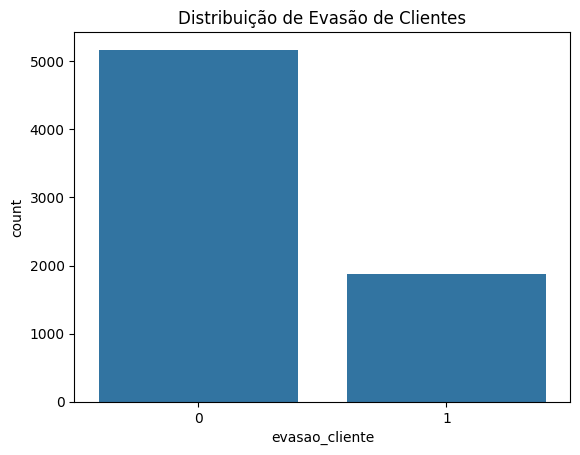

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='evasao_cliente', data=df)
plt.title("Distribuição de Evasão de Clientes")
plt.show()

# Remoção de Colunas Irrelevantes

In [5]:
df = df.drop(columns=['id_cliente','cobranca_total','contas_diarias'])

In [6]:
# Avaliando a relevancia da features

corr = df.corr(numeric_only=True)
corr['evasao_cliente'].sort_values(ascending=False)

,evasao_cliente
evasao_cliente,1.000000
cobranca_mensal,0.193356
fatura_digital,0.191825
idoso_65_ou_mais,0.150889
streaming_tv,0.063228
streaming_filmes,0.061382
multiplas_linhas,0.040102
servico_telefonico,0.011942
genero,-0.008612
protecao_dispositivo,-0.066160


In [7]:
df = df.drop(columns='genero')

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# converter categóricas
for col in df_model.select_dtypes(include='object'):
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

X = df_model.drop('evasao_cliente', axis=1)
y = df_model['evasao_cliente']

model = RandomForestClassifier()
model.fit(X, y)

importances = model.feature_importances_

importance_df = pd.DataFrame({
    'variavel': X.columns,
    'importancia': importances
}).sort_values(by='importancia', ascending=False)

print(importance_df)

                variavel  importancia
16       cobranca_mensal     0.270512
3   tempo_contrato_meses     0.248761
13         tipo_contrato     0.095417
15      metodo_pagamento     0.064777
6       servico_internet     0.043556
14        fatura_digital     0.030163
1        possui_parceiro     0.027705
7       seguranca_online     0.027008
10       suporte_tecnico     0.025732
8          backup_online     0.025467
0       idoso_65_ou_mais     0.024643
2     possui_dependentes     0.023486
9   protecao_dispositivo     0.023340
5       multiplas_linhas     0.022168
12      streaming_filmes     0.020124
11          streaming_tv     0.019505
4     servico_telefonico     0.007636


In [9]:
df = df.drop(columns='servico_telefonico')

In [10]:
df.head()

,evasao_cliente,idoso_65_ou_mais,possui_parceiro,possui_dependentes,tempo_contrato_meses,multiplas_linhas,servico_internet,seguranca_online,backup_online,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,cobranca_mensal
0,0,0,1,1,9,0,DSL,0,1,0,1,1,0,Anual,1,Cheque,65.6
1,0,0,0,0,9,1,DSL,0,0,0,0,0,1,Mensal,0,Cheque,59.9
2,1,0,0,0,4,0,Fiber optic,0,0,1,0,0,0,Mensal,1,Cheque eletrônico,73.9
3,1,1,1,0,13,0,Fiber optic,0,1,1,0,1,1,Mensal,1,Cheque eletrônico,98.0
4,1,1,1,0,3,0,Fiber optic,0,0,0,1,1,0,Mensal,1,Cheque,83.9


# Encoding

In [11]:
X = df.drop('evasao_cliente', axis=1)
y = df['evasao_cliente']

In [12]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

colunas_categoricas = ['tipo_contrato','metodo_pagamento','servico_internet']
one_hot_enc = make_column_transformer(
    (OneHotEncoder(handle_unknown = 'ignore'),
    colunas_categoricas),
    remainder='passthrough')
X = one_hot_enc.fit_transform(X)
X = pd.DataFrame(X, columns=one_hot_enc.get_feature_names_out())
X

,onehotencoder__tipo_contrato_Anual,onehotencoder__tipo_contrato_Bianual,onehotencoder__tipo_contrato_Mensal,onehotencoder__metodo_pagamento_Cartão de crédito,onehotencoder__metodo_pagamento_Cheque,onehotencoder__metodo_pagamento_Cheque eletrônico,onehotencoder__metodo_pagamento_Transferência Bancária,onehotencoder__servico_internet_DSL,onehotencoder__servico_internet_Fiber optic,onehotencoder__servico_internet_No,...,remainder__tempo_contrato_meses,remainder__multiplas_linhas,remainder__seguranca_online,remainder__backup_online,remainder__protecao_dispositivo,remainder__suporte_tecnico,remainder__streaming_tv,remainder__streaming_filmes,remainder__fatura_digital,remainder__cobranca_mensal
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,9.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,65.60
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,9.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,59.90
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,4.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,73.90
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,13.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,98.00
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,3.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,13.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,55.15
7039,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,22.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,85.10
7040,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,50.30
7041,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,67.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,67.85


In [13]:
X.columns = X.columns.str.replace('onehotencoder__', '', regex=False)
X.columns = X.columns.str.replace('remainder__', '', regex=False)

# Normalização

In [14]:
from sklearn.preprocessing import MinMaxScaler

normalizacao = MinMaxScaler()
x_normalizado = normalizacao.fit_transform(X)

pd.DataFrame(x_normalizado)

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.125000,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.471144
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.125000,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.414428
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.055556,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.553731
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.180556,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.793532
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.041667,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.653234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.180556,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.367164
7039,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.305556,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.665174
7040,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.027778,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.318905
7041,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.930556,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.493532


# Análise de Correlação

In [15]:
df_corr = X.copy()
df_corr['evasao_cliente'] = y
corr = df_corr.corr()

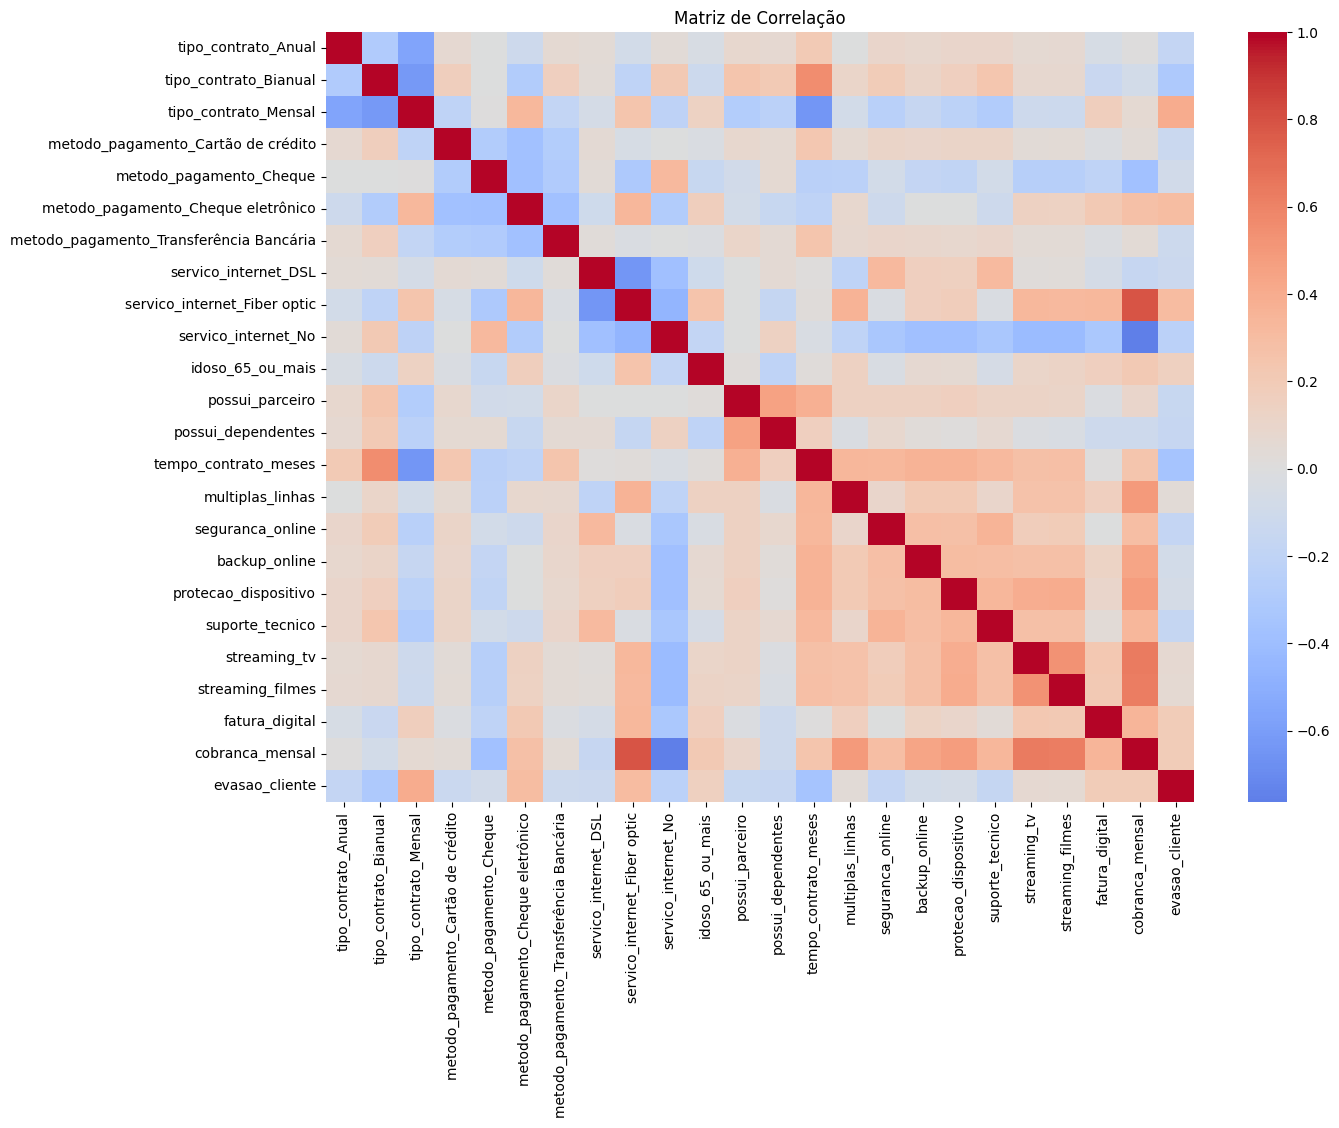

In [16]:
plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação')
plt.show()

# Análises Direcionadas

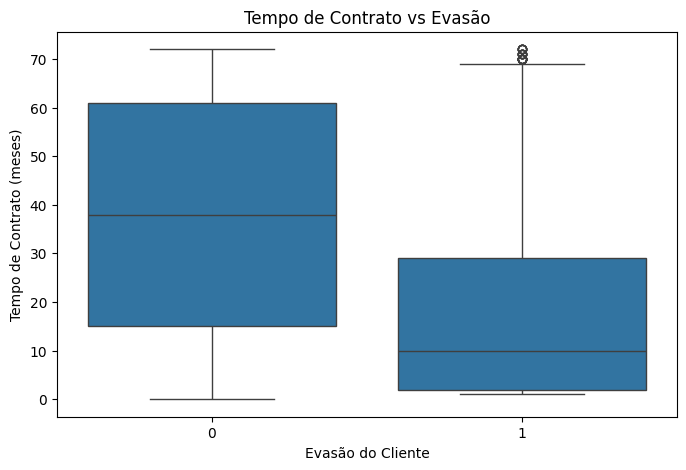

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x='evasao_cliente', y='tempo_contrato_meses', data=df_corr)

plt.title('Tempo de Contrato vs Evasão')
plt.xlabel('Evasão do Cliente')
plt.ylabel('Tempo de Contrato (meses)')

plt.show()

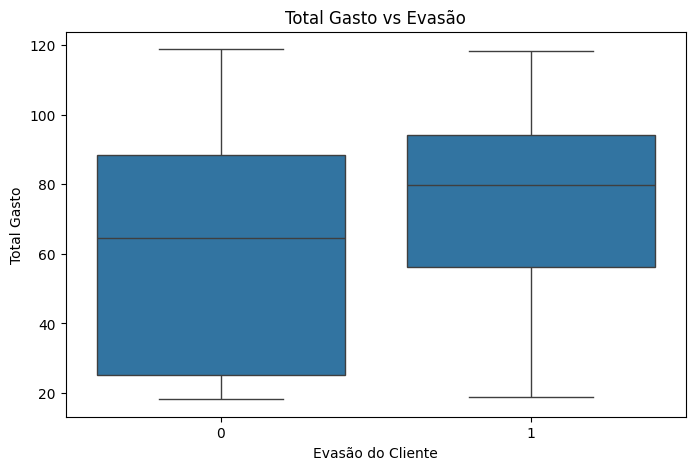

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='evasao_cliente', y='cobranca_mensal', data=df_corr)

plt.title('Total Gasto vs Evasão')
plt.xlabel('Evasão do Cliente')
plt.ylabel('Total Gasto')

plt.show()

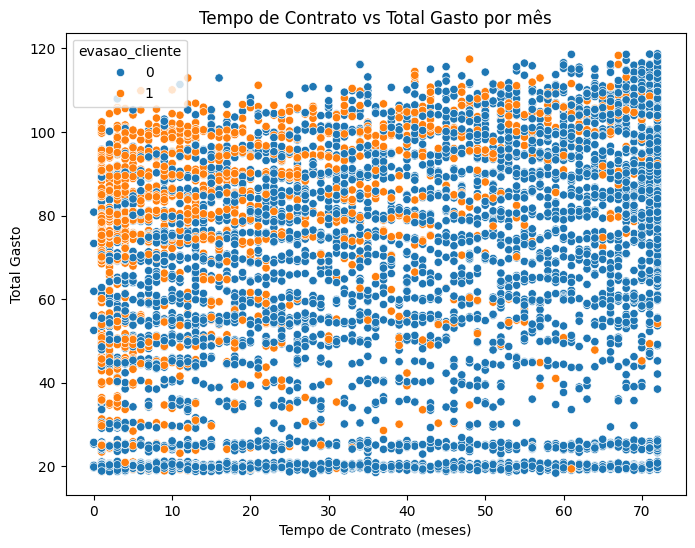

In [19]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='tempo_contrato_meses',
    y='cobranca_mensal',
    hue='evasao_cliente',
    data=df
)

plt.title('Tempo de Contrato vs Total Gasto por mês')
plt.xlabel('Tempo de Contrato (meses)')
plt.ylabel('Total Gasto')

plt.show()

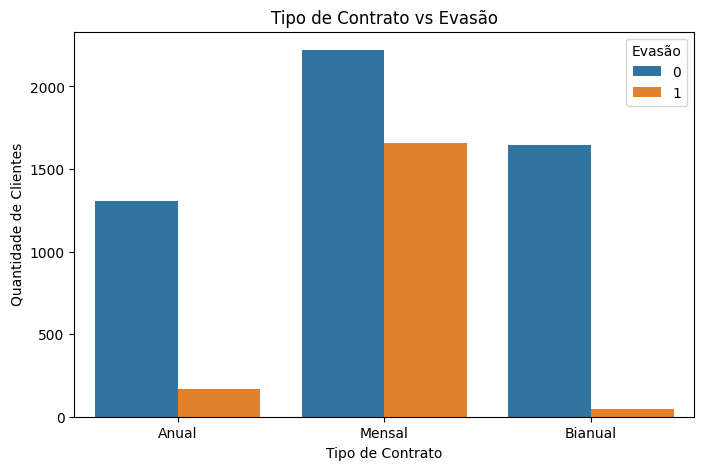

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='tipo_contrato',
    hue='evasao_cliente',
    data=df
)

plt.title('Tipo de Contrato vs Evasão')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Evasão')

plt.show()

# Separação de Dados

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=64,
    stratify=y
)

In [22]:
# Dados Normalizados

X_train_norm, X_test_norm, y_train_norm, y_test_norm = train_test_split(
    x_normalizado,
    y,
    test_size=0.2,
    random_state=92,
    stratify=y
)

# Criação de Modelos
# * Modelo base




In [45]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="stratified")
baseline.fit(X_train, y_train)

DummyClassifier(strategy='stratified')

In [46]:
y_pred_base = baseline.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def calcular_metricas_classificacao(y_test, y_pred):

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    metricas = {
        'Accuracy': round(acc, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-score': round(f1, 4)
    }

    return metricas

In [48]:
calcular_metricas_classificacao(y_test, y_pred_base)

{'Accuracy': 0.6097, 'Precision': 0.2811, 'Recall': 0.3021, 'F1-score': 0.2912}

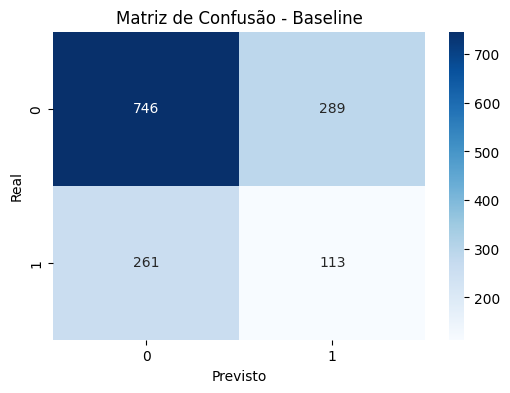

In [57]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Baseline")

plt.show()

# * Modelo KNN

In [30]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_norm, y_train)

KNeighborsClassifier()

In [31]:
y_pred_knn = knn.predict(X_test_norm)

In [32]:
calcular_metricas_classificacao(y_test, y_pred_knn)

{'Accuracy': 0.6842, 'Precision': 0.2517, 'Recall': 0.0963, 'F1-score': 0.1393}

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.73      0.90      0.81      1035
           1       0.25      0.10      0.14       374

    accuracy                           0.68      1409
   macro avg       0.49      0.50      0.47      1409
weighted avg       0.61      0.68      0.63      1409



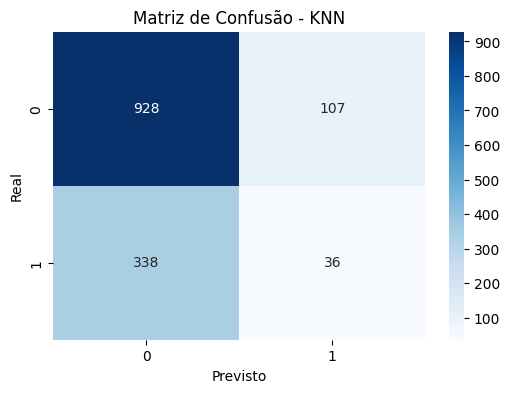

In [56]:
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - KNN")

plt.show()

# * Modelo arvore de decisão

In [50]:
from sklearn.tree import DecisionTreeClassifier

arvore = DecisionTreeClassifier(max_depth=3,random_state=73)
arvore.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=73)

In [51]:
y_pred_arvore = arvore.predict(X_test)

In [52]:
calcular_metricas_classificacao(y_test, y_pred_arvore)

{'Accuracy': 0.7842, 'Precision': 0.7059, 'Recall': 0.3209, 'F1-score': 0.4412}

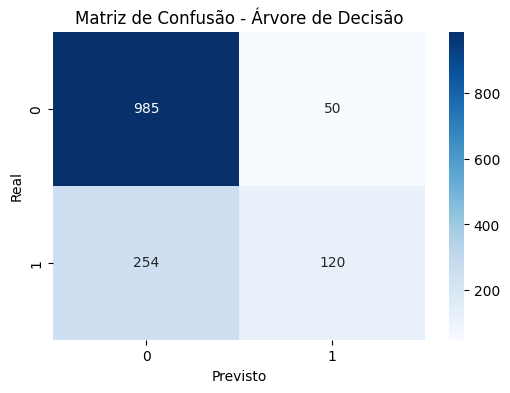

In [55]:
cm = confusion_matrix(y_test, y_pred_arvore)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Árvore de Decisão")

plt.show()

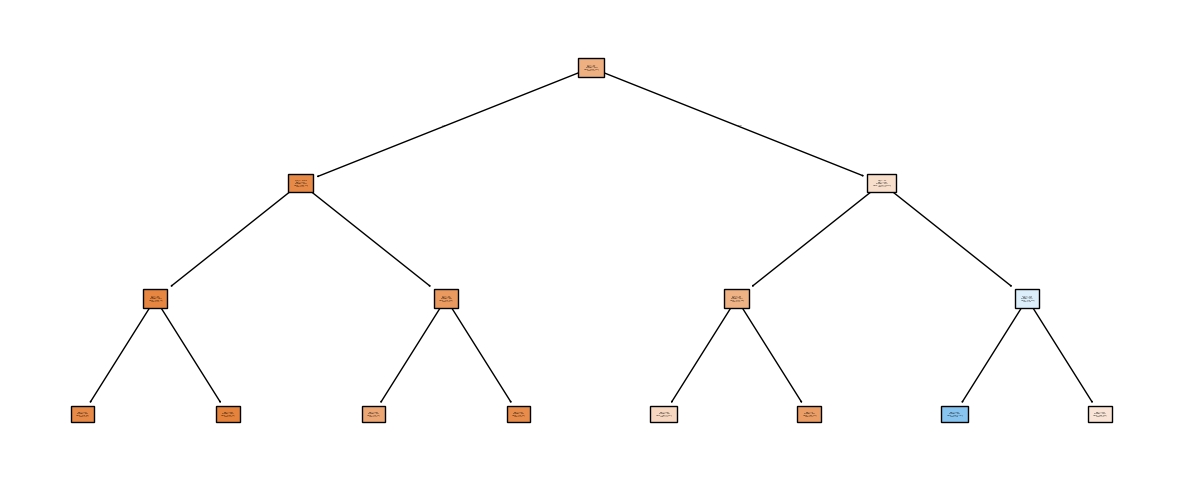

In [53]:
from sklearn.tree import plot_tree

plt.figure(figsize = (15, 6))
plot_tree(arvore, filled = True, class_names = ['nao', 'sim'], fontsize = 1);

# Comparação dos modelos

In [59]:
# calcular métricas de cada modelo
metricas_dummy = calcular_metricas_classificacao(y_test, y_pred_base)
metricas_knn = calcular_metricas_classificacao(y_test, y_pred_knn)
metricas_arvore = calcular_metricas_classificacao(y_test, y_pred_arvore)

# criar tabela comparativa
tabela_modelos = pd.DataFrame({
    'Dummy': metricas_dummy,
    'KNN': metricas_knn,
    'Árvore de Decisão': metricas_arvore
}).T

tabela_modelos

,Accuracy,Precision,Recall,F1-score
Dummy,0.6097,0.2811,0.3021,0.2912
KNN,0.6842,0.2517,0.0963,0.1393
Árvore de Decisão,0.7842,0.7059,0.3209,0.4412


A comparação entre os modelos mostrou que o modelo baseline (DummyClassifier) apresentou desempenho limitado, caracterizando underfitting, pois não conseguiu identificar clientes que cancelaram o serviço.

O modelo KNN apresentou melhora em relação ao baseline, indicando que a utilização da proximidade entre os dados permite capturar alguns padrões associados à evasão.

A árvore de decisão apresentou o melhor desempenho entre os modelos avaliados, demonstrando maior capacidade de identificar relações entre as variáveis e a evasão dos clientes. No entanto, esse tipo de modelo pode apresentar overfitting quando não há restrições em sua profundidade, sendo recomendável ajustar hiperparâmetros como max_depth e min_samples_leaf para melhorar a generalização.

# Random Forest — importância das variáveis

In [61]:
importancias = pd.DataFrame({
    'Variavel': X_train.columns,
    'Importancia': arvore.feature_importances_
})

importancias = importancias.sort_values(by='Importancia', ascending=False)

importancias

,Variavel,Importancia
2,tipo_contrato_Mensal,0.607023
8,servico_internet_Fiber optic,0.189999
13,tempo_contrato_meses,0.162409
22,cobranca_mensal,0.023701
1,tipo_contrato_Bianual,0.016867
3,metodo_pagamento_Cartão de crédito,0.000000
0,tipo_contrato_Anual,0.000000
6,metodo_pagamento_Transferência Bancária,0.000000
5,metodo_pagamento_Cheque eletrônico,0.000000
4,metodo_pagamento_Cheque,0.000000


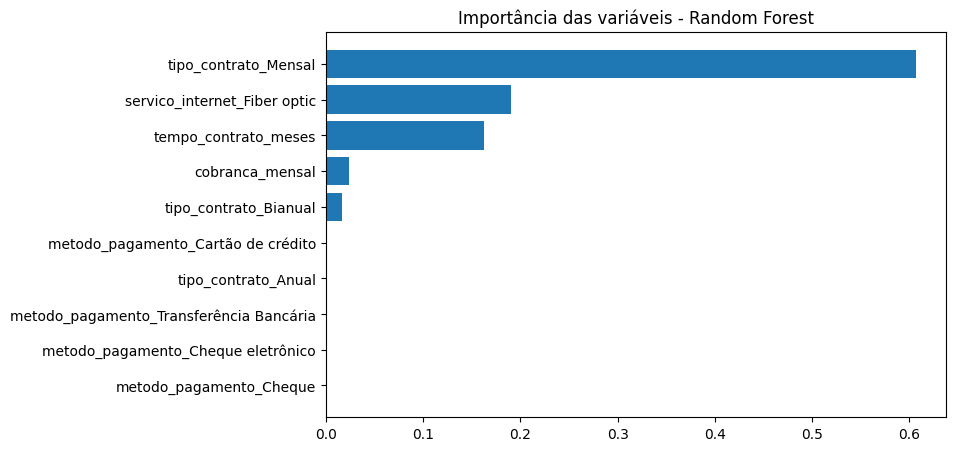

In [62]:
top_features = importancias.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features['Variavel'], top_features['Importancia'])

plt.title("Importância das variáveis - Random Forest")
plt.gca().invert_yaxis()

plt.show()

A análise das variáveis mais relevantes mostrou que fatores relacionados ao tempo de relacionamento do cliente com a empresa e ao tipo de contrato possuem forte influência na evasão. Modelos como a regressão logística indicaram coeficientes elevados para variáveis associadas a contratos mais curtos, enquanto o Random Forest destacou a importância de variáveis como tempo de contrato e valor total gasto. Esses resultados sugerem que clientes com contratos mensais e menor tempo de permanência apresentam maior probabilidade de cancelar o serviço.